In [1]:
import math
import collections
import matplotlib.pyplot as plt

In [2]:
with open("sequence.txt", "r") as file:
    original_sequences = file.read()
    original_sequences = [list(original_sequences.split("\n")[i][15:]) for i in range(0, 64, 8)]
  

In [3]:
def encode_rle(sequence):
    result = []
    count = 1

    for i, item in enumerate(sequence):
        if i == 0:
            continue
        elif item == sequence[i - 1]:
            count += 1
        else:
            result.append((sequence[i - 1], count))
            count = 1
    result.append((sequence[len(sequence) - 1], count))

    encoded = []
    for i, item in enumerate(result):
        encoded.append(f"{item[1]}{item[0]}")
    
    return "".join(encoded), result

In [4]:
def decode_rle(sequence):
    result = []
    for item in sequence:
        result.append(item[0] * item[1])
    return "".join(result)

In [5]:
def encode_lzw(sequence):
    dictionary = {}
    for i in range(65536):
        dictionary[chr(i)] = i
    
    result = []
    current = ""
    total = 0
    size = 0
    for c in sequence:
        
        new_str = current + c
        
        if new_str in dictionary:
            current = new_str
        else:
            result.append(dictionary[current])
            dictionary[new_str] = len(dictionary)
            
            current = c

            element_bits = 16 if dictionary[current] < 65536 else math.ceil(math.log2(len(dictionary)))

            with open("results_rle_lzw.txt", "a") as file:
                file.write(f"Code: {dictionary[current]}, Element: {current}, bits: {element_bits}\n")
            size = size + element_bits

    last = 16 if dictionary[current] < 65536 else math.ceil(math.log2(len(dictionary)))
    size = size + last
    compression_ratio_LZW = round((len(sequence) * 16 / size), 2)

    with open("results_rle_lzw.txt", "a") as file:
        file.write(f"Code: {dictionary[current]}, Element: {current}, Bits: {last}\n")
        file.write(f"Code: {dictionary[current]}, Element: {current}, Bits: {last}\n")
        result.append(dictionary[current])
        file.write("__________\n")
        file.write(f"Закодована LZW послідовність:{''.join(map(str, result))} \n")
        file.write(f"Розмір закодованої LZW послідовності: { size } біт \n")
        file.write(f"Коефіцієнт стиснення LZV: { compression_ratio_LZW }\n")

    return result, compression_ratio_LZW

In [6]:
def decode_zlw(sequence):
    dictionary = {}
    for i in range(65536):
        dictionary[i] = chr(i)

    result = ""
    previous = None
    current = ""

    for code in sequence:
        if code in dictionary:
            current = dictionary[code]
            result += current
            if previous is not None:
                dictionary[len(dictionary)] = previous + current[0]
            previous = current
        else:
            current = previous + previous[0]
            result += current
            dictionary[len(dictionary)] = current
            previous = current
    return result

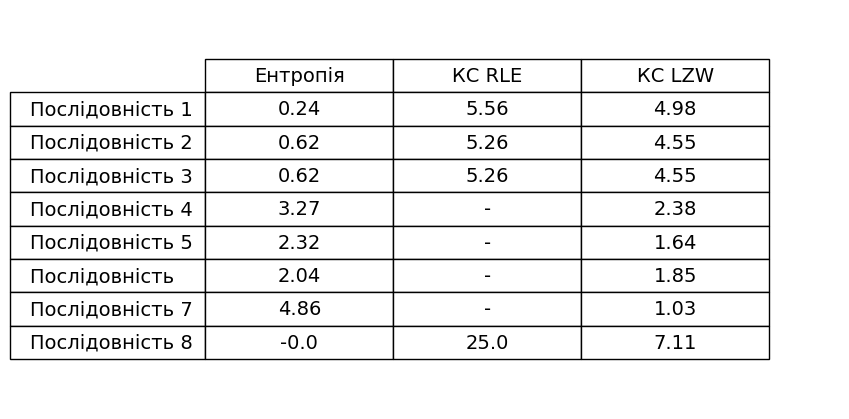

In [7]:
N_sequence = 100
results = []
N = 8

for sequence in original_sequences:
    counts = collections.Counter(sequence)
    probability = {symbol: count / N_sequence for symbol, count in counts.items()}
    entropy = -sum(p * math.log2(p) for p in probability.values())

    encoded_sequence, encoded = encode_rle(sequence)
    size_encoded_sequence = len(encoded_sequence) * 16
    compression_ratio_RLE = round((len(sequence)/len(encoded_sequence)), 2)
    if compression_ratio_RLE < 1:
        compression_ratio_RLE = '-'
    else:
        compression_ratio_RLE = compression_ratio_RLE

    decoded = decode_rle(encoded)

    with open("results_rle_lzw.txt", "a") as file:
        file.write(f"Послідовність: {''.join(map(str, sequence))}\n" 
                   + "Розмір оригінальної послідовності 1600 біт\n" 
                   + f"Ентропія: {entropy}\n"
                   + "_____Кодування_RLE______\n"
                   + f"Закодована RLE послідовність: {encoded_sequence}\n" 
                   + f"Розмір закодованої послідовності: {size_encoded_sequence} біт\n"
                   + f"Коефіцієнт стиснення RLE: {compression_ratio_RLE}\n"
                   + f"Декодована RLE послідовність: {decoded}\n"
                   + f"Розмір декодованої RLE послідовності: {len(decoded) * 16} біт\n"
                   + "_____Кодування_LZW_____\n"
                   + "_____Словник_____\n")
        
    encoded_sequence, compression_ratio_LZW = encode_lzw(sequence)
    decoded = decode_zlw(encoded_sequence)

    with open("results_rle_lzw.txt", "a") as file:
        file.write(f"Декодована LZW послідовність: {decoded}\n" 
                   + f"Розмір декодованої LZW послідовності: {len(decoded) * 16} біт\n")
    
    results.append([round((entropy), 2), compression_ratio_RLE, compression_ratio_LZW])
    
fig, ax = plt.subplots(figsize=(14/1.54, N/1.54))
headers = ["Ентропія", "КС RLE", "КС LZW"]
row = ["Послідовність 1", "Послідовність 2", "Послідовність 3", "Послідовність 4", "Послідовність 5", "Послідовність ", "Послідовність 7", "Послідовність 8"]
ax.axis('off')
table = ax.table(cellText=results, colLabels=headers, rowLabels=row, loc='center' , cellLoc='center')
table.set_fontsize(14)
table.scale(0.8, 2)
plt.savefig("./Результати стиснення методами RLE та LZW.png")
    
